In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import (train_test_split,
                                         GridSearchCV,
                                         KFold)
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.svm import SVR
import shap
import lime
import lime.lime_tabular

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.linear_model import LinearRegression,SGDRegressor,Lasso,Ridge
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    mean_absolute_percentage_error
)

C:\Users\savin\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Load dataset

In [2]:
df = pd.read_csv('formatted_data.csv')
df.head()

,Brand,Model,YOM,Mileage,Gear,Fuel Type,Engine (cc),Condition,Ad Date,Location,...,Number of Cylinders,Power Steering,Power Shutters,Power Mirrors,Manufacturing Country,Model_cleaned,Mileage_numeric,Price_numeric,Ad_Date_Clean_Str,Ad_Date_clean
0,Audi,A3 Sline,2018,93000.0,Automatic,Petrol,1000.0,Registered (Used),"2026 Jun 05, 11:39 am",Colombo,...,3.0,Yes,Yes,Yes,Germany,a3sline,93000.0,14400000.0,2026 Jun 05,2026-06-05
1,Audi,A1 Sline,2017,96000.0,Automatic,Petrol,990.0,Registered (Used),"2026 Jun 06, 10:27 pm",Kandy,...,3.0,Yes,Yes,Yes,Germany,a1sline,96000.0,8650000.0,2026 Jun 06,2026-06-06
2,Audi,A1 Highest Spec,2016,86000.0,Automatic,Petrol,10000.0,Registered (Used),"2026 Jul 19, 9:58 am",Colombo,...,6.0,Yes,Yes,Yes,Germany,a1highestspec,86000.0,8200000.0,2026 Jul 19,2026-07-19
3,Audi,A1,2017,69000.0,Automatic,Petrol,1000.0,Registered (Used),"2026 Jul 27, 5:36 pm",Bandaragama,...,3.0,Yes,Yes,Yes,Germany,a1,69000.0,8700000.0,2026 Jul 27,2026-07-27
4,Audi,A1,2016,55000.0,Automatic,Petrol,1000.0,Registered (Used),"2026 Jul 28, 12:06 am",Bandaragama,...,3.0,Yes,Yes,Yes,Germany,a1,55000.0,9500000.0,2026 Jul 28,2026-07-28


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6436 entries, 0 to 6435
Data columns (total 23 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Brand                  6436 non-null   object 
 1   Model                  6436 non-null   object 
 2   YOM                    6436 non-null   int64  
 3   Mileage                6418 non-null   float64
 4   Gear                   6436 non-null   object 
 5   Fuel Type              6436 non-null   object 
 6   Engine (cc)            6258 non-null   float64
 7   Condition              6436 non-null   object 
 8   Ad Date                6436 non-null   object 
 9   Location               6436 non-null   object 
 10  Price                  6436 non-null   object 
 11  URL                    6436 non-null   object 
 12  Body Type              6436 non-null   object 
 13  Number of Cylinders    6218 non-null   float64
 14  Power Steering         6436 non-null   object 
 15  Powe

In [4]:
df.describe()

,YOM,Mileage,Engine (cc),Number of Cylinders,Mileage_numeric,Price_numeric
count,6436.000000,6418.000000,6258.000000,6218.000000,6418.000000,4.996000e+03
mean,2011.818832,119121.983172,1510.105944,3.730621,119121.983172,9.516305e+06
std,9.933976,72099.259303,3707.723169,0.570266,72099.259303,6.351091e+06
min,1972.000000,0.000000,1.000000,0.000000,0.000000,3.450000e+03
25%,2007.000000,72000.000000,1000.000000,3.000000,72000.000000,5.700000e+06
50%,2014.000000,123000.000000,1490.000000,4.000000,123000.000000,8.200000e+06
75%,2018.000000,166000.000000,1500.000000,4.000000,166000.000000,1.195000e+07
max,2026.000000,856648.000000,149000.000000,8.000000,856648.000000,1.400000e+08


Clean Dataset

In [5]:
df = df.drop_duplicates()
df = df.dropna(subset=["Price_numeric", "Mileage_numeric", "Number of Cylinders", "Engine (cc)", "YOM"])
df = df[(df["Engine (cc)"] > 0) & (df["Engine (cc)"] < 10_000)]
df = df[df["Condition"] != "Antique"]

n_before = len(df)
df = df[df["Price_numeric"] >= 50000]
print(f"Dropped {n_before - len(df)} row(s) with implausible Price_numeric < Rs.{50000:,} "
      f"(these are almost certainly data-entry/scraping errors, e.g. Price_numeric=3,450)")

# keep models with >=2 records, and (model, condition) groups with >=3 records,
# so a stratified split is possible
model_counts = df["Model_cleaned"].value_counts()
df = df[df["Model_cleaned"].isin(model_counts[model_counts >= 2].index)]

df["strat_col"] = list(zip(df["Model_cleaned"], df["Condition"]))
strat_counts = df["strat_col"].value_counts()
df = df[df["strat_col"].isin(strat_counts[strat_counts >= 3].index)]

print(f"Rows after cleaning: {len(df)}")



Dropped 1 row(s) with implausible Price_numeric < Rs.50,000 (these are almost certainly data-entry/scraping errors, e.g. Price_numeric=3,450)
Rows after cleaning: 4002


Fearture Engineering

In [6]:
CURRENT_YEAR = 2026
df["Car_Age"] = CURRENT_YEAR - df["YOM"]
df['Millage_per_year'] = df['Mileage_numeric']/df['Car_Age']


In [7]:
df.head()

,Brand,Model,YOM,Mileage,Gear,Fuel Type,Engine (cc),Condition,Ad Date,Location,...,Power Mirrors,Manufacturing Country,Model_cleaned,Mileage_numeric,Price_numeric,Ad_Date_Clean_Str,Ad_Date_clean,strat_col,Car_Age,Millage_per_year
0,Audi,A3 Sline,2018,93000.0,Automatic,Petrol,1000.0,Registered (Used),"2026 Jun 05, 11:39 am",Colombo,...,Yes,Germany,a3sline,93000.0,14400000.0,2026 Jun 05,2026-06-05,"(a3sline, Registered (Used))",8,11625.000000
3,Audi,A1,2017,69000.0,Automatic,Petrol,1000.0,Registered (Used),"2026 Jul 27, 5:36 pm",Bandaragama,...,Yes,Germany,a1,69000.0,8700000.0,2026 Jul 27,2026-07-27,"(a1, Registered (Used))",9,7666.666667
4,Audi,A1,2016,55000.0,Automatic,Petrol,1000.0,Registered (Used),"2026 Jul 28, 12:06 am",Bandaragama,...,Yes,Germany,a1,55000.0,9500000.0,2026 Jul 28,2026-07-28,"(a1, Registered (Used))",10,5500.000000
5,Audi,A1,2016,67000.0,Automatic,Petrol,999.0,Registered (Used),"2026 May 25, 1:57 pm",Colombo,...,Yes,Germany,a1,67000.0,9000000.0,2026 May 25,2026-05-25,"(a1, Registered (Used))",10,6700.000000
7,Audi,A1,2015,104000.0,Automatic,Petrol,1000.0,Registered (Used),"2026 May 28, 2:21 pm",Colombo,...,Yes,Germany,a1,104000.0,8200000.0,2026 May 28,2026-05-28,"(a1, Registered (Used))",11,9454.545455


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4002 entries, 0 to 6433
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Brand                  4002 non-null   object 
 1   Model                  4002 non-null   object 
 2   YOM                    4002 non-null   int64  
 3   Mileage                4002 non-null   float64
 4   Gear                   4002 non-null   object 
 5   Fuel Type              4002 non-null   object 
 6   Engine (cc)            4002 non-null   float64
 7   Condition              4002 non-null   object 
 8   Ad Date                4002 non-null   object 
 9   Location               4002 non-null   object 
 10  Price                  4002 non-null   object 
 11  URL                    4002 non-null   object 
 12  Body Type              4002 non-null   object 
 13  Number of Cylinders    4002 non-null   float64
 14  Power Steering         4002 non-null   object 
 15  Power Shu

In [9]:
df.describe()

C:\Users\savin\AppData\Roaming\Python\Python314\site-packages\pandas\core\nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


,YOM,Mileage,Engine (cc),Number of Cylinders,Mileage_numeric,Price_numeric,Car_Age,Millage_per_year
count,4002.000000,4002.000000,4002.000000,4002.000000,4002.000000,4.002000e+03,4002.000000,3.946000e+03
mean,2011.768866,123644.259120,1344.161919,3.708896,123644.259120,9.190002e+06,14.231134,inf
std,9.423593,72141.243389,410.111801,0.526684,72141.243389,5.584190e+06,9.423593,NaN
min,1973.000000,0.000000,1.000000,2.000000,0.000000,1.700000e+05,0.000000,0.000000e+00
25%,2007.000000,80000.000000,1000.000000,3.000000,80000.000000,5.700000e+06,8.000000,6.818182e+03
50%,2014.000000,128000.000000,1490.000000,4.000000,128000.000000,7.975000e+06,12.000000,9.300000e+03
75%,2018.000000,170000.000000,1500.000000,4.000000,170000.000000,1.123750e+07,19.000000,1.214068e+04
max,2026.000000,856648.000000,3500.000000,8.000000,856648.000000,6.500000e+07,53.000000,inf


EDA

In [10]:
count = (df['Price_numeric'] > 10000000).sum()
print(count)

1231


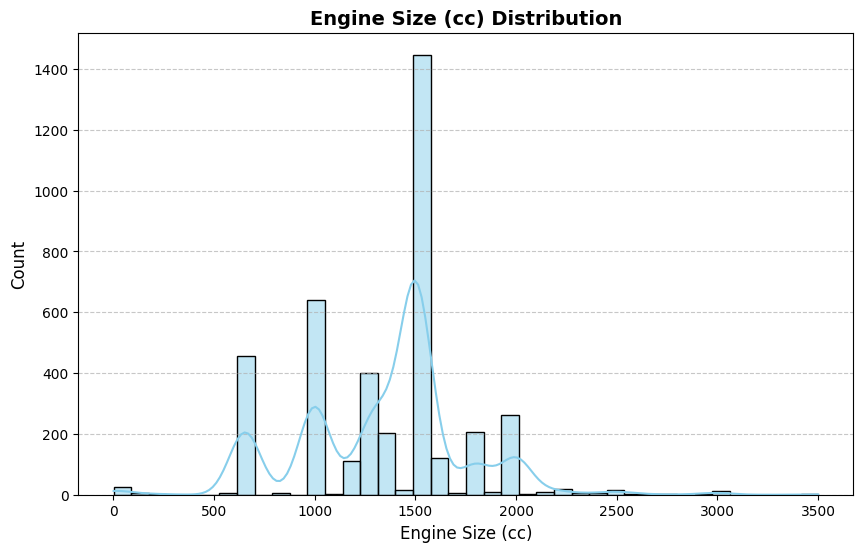

In [11]:
# 2. Set up the figure size for better readability
plt.figure(figsize=(10, 6))

# 3. Plot with increased bins and a KDE curve to show distribution shape
sns.histplot(
    data=df, 
    x="Engine (cc)", 
    bins=40,          # More bins give a finer, smoother look
    kde=True,         # Adds a density probability curve
    color="skyblue", 
    edgecolor="black"
)

# 4. Styling the plot
plt.title("Engine Size (cc) Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Engine Size (cc)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.savefig('fig/Engine SIze(cc) Distribution')
plt.show()



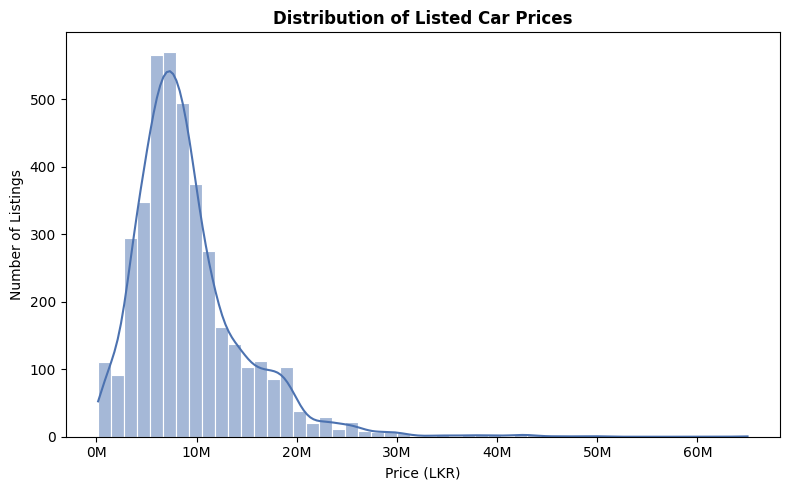

In [12]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="Price_numeric", bins=50, kde=True, color="#4C72B0", edgecolor="white")
plt.title("Distribution of Listed Car Prices", fontweight="bold")
plt.xlabel("Price (LKR)"); plt.ylabel("Number of Listings")
plt.ticklabel_format(style='plain', axis='x')
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M'))
plt.tight_layout()
plt.savefig('fig/price_distribution.png', dpi=150)
plt.show()

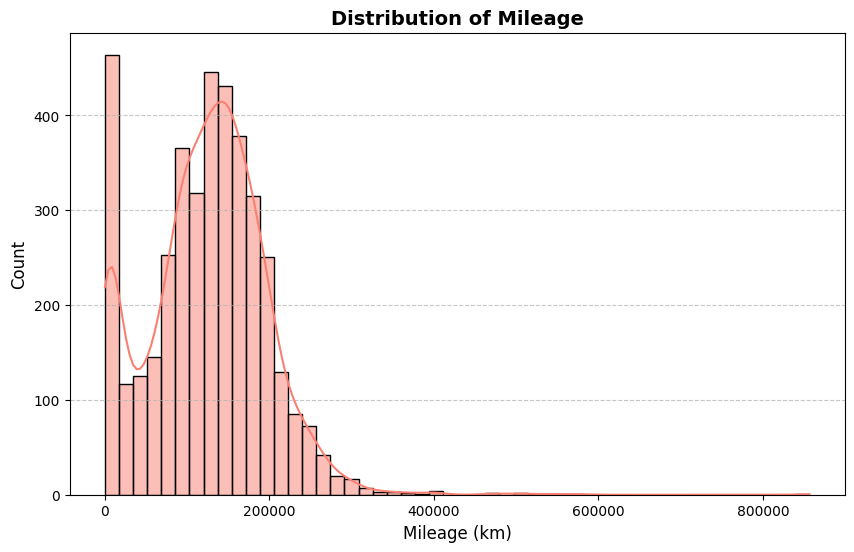

In [13]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Mileage_numeric",
    bins=50,
    kde=True,
    color="salmon",
    edgecolor="black"
)
plt.title("Distribution of Mileage", fontsize=14, fontweight="bold")
plt.xlabel("Mileage (km)", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.savefig('fig/Mileage Distribution')
plt.show()

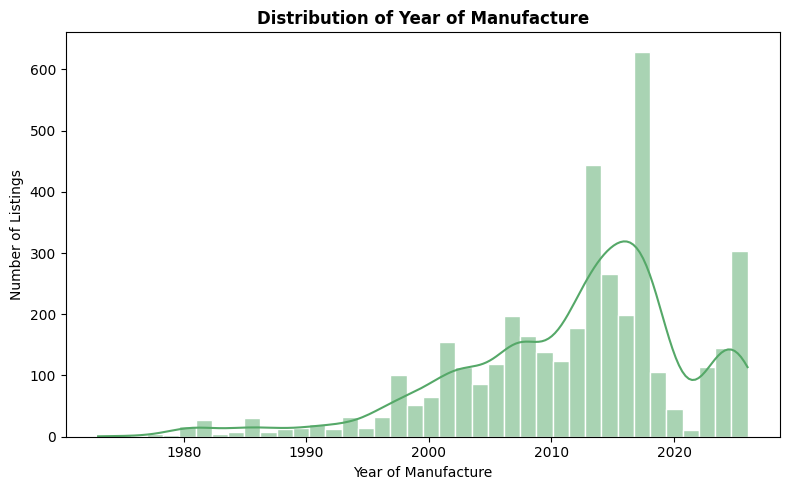

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(data=df, x="YOM", bins=40, kde=True, color="#55A868", edgecolor="white")
plt.title("Distribution of Year of Manufacture", fontweight="bold")
plt.xlabel("Year of Manufacture"); plt.ylabel("Number of Listings")
plt.tight_layout()
plt.savefig('fig/YOM Distribution', dpi=150) 
plt.show()

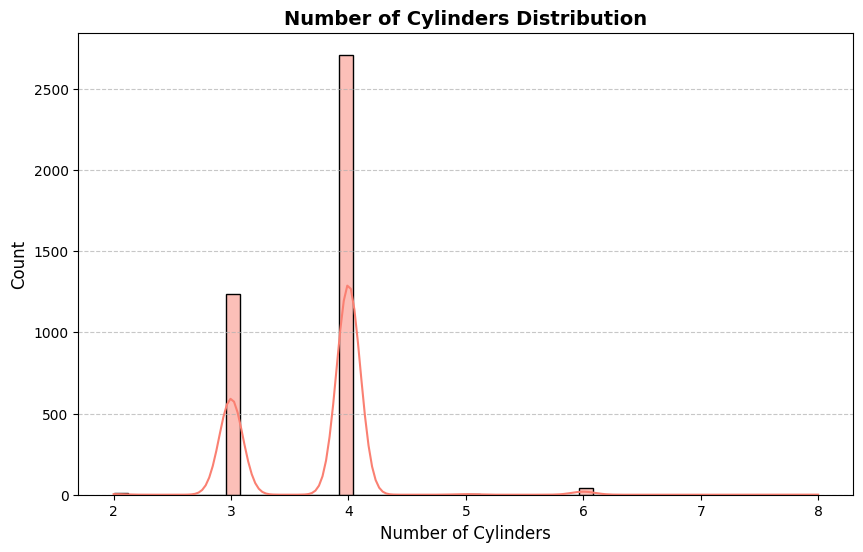

In [15]:
plt.figure(figsize=(10, 6))

sns.histplot(
    data=df,
    x="Number of Cylinders",
    bins=50,
    kde=True,
    color="salmon",
    edgecolor="black"
)
plt.title("Number of Cylinders Distribution", fontsize=14, fontweight="bold")
plt.xlabel("Number of Cylinders", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.savefig('fig/Number of cylinders Distribution')
plt.show()

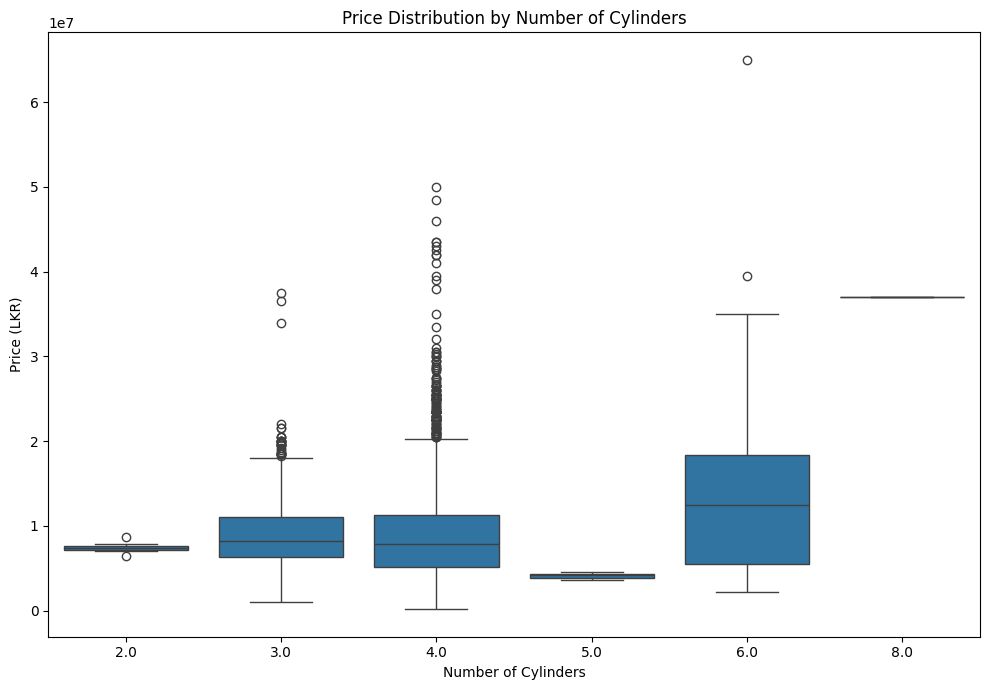

In [16]:
plt.figure(figsize=(10, 7))

sns.boxplot(
    data=df,
    x='Number of Cylinders',
    y='Price_numeric'
)

plt.title('Price Distribution by Number of Cylinders')
plt.xlabel('Number of Cylinders')
plt.ylabel('Price (LKR)')
plt.tight_layout()
plt.savefig('fig/Price Distribution by Number of Cylinders')
plt.show()

C:\Users\savin\AppData\Local\Temp\ipykernel_24108\3145628885.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Fuel Type', y='Price_numeric', order=order, showfliers=False, palette='Set2')


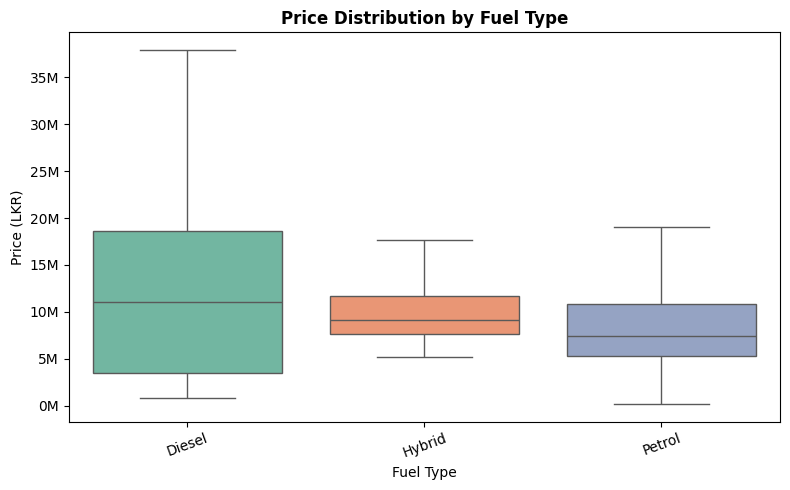

In [17]:
plt.figure(figsize=(8,5))
order = df.groupby('Fuel Type')['Price_numeric'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Fuel Type', y='Price_numeric', order=order, showfliers=False, palette='Set2')
plt.title("Price Distribution by Fuel Type", fontweight="bold")
plt.xlabel("Fuel Type"); plt.ylabel("Price (LKR)")
plt.xticks(rotation=20)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M'))
plt.tight_layout(); plt.savefig('fig/price_by_fueltype.png', dpi=150); plt.show()

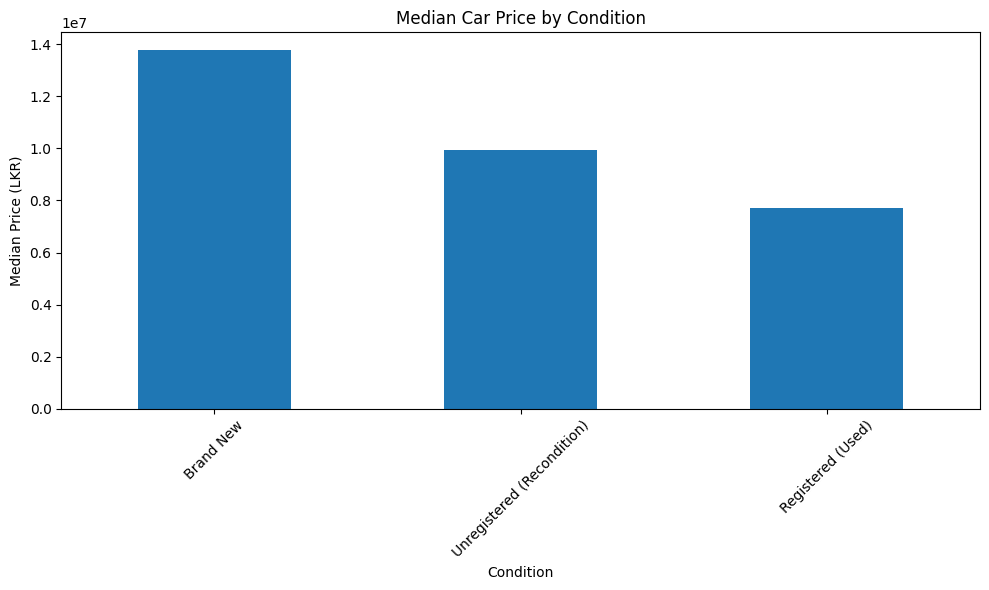

In [18]:
condition_price = (
    df.groupby('Condition')['Price_numeric']
      .median()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

condition_price.plot(kind='bar')

plt.title('Median Car Price by Condition')
plt.xlabel('Condition')
plt.ylabel('Median Price (LKR)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('fig/Median car price by condition')
plt.show()

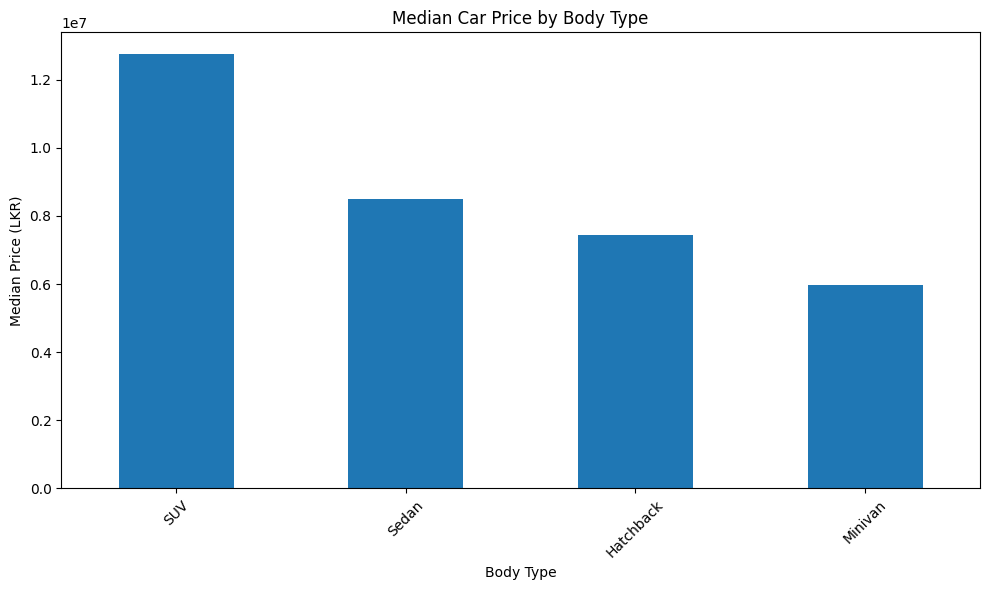

In [19]:
condition_price = (
    df.groupby('Body Type')['Price_numeric']
      .median()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

condition_price.plot(kind='bar')

plt.title('Median Car Price by Body Type')
plt.xlabel('Body Type')
plt.ylabel('Median Price (LKR)')
plt.xticks(rotation=45)
plt.savefig('fig/Mediancar price by Body Type')
plt.tight_layout()
plt.show()

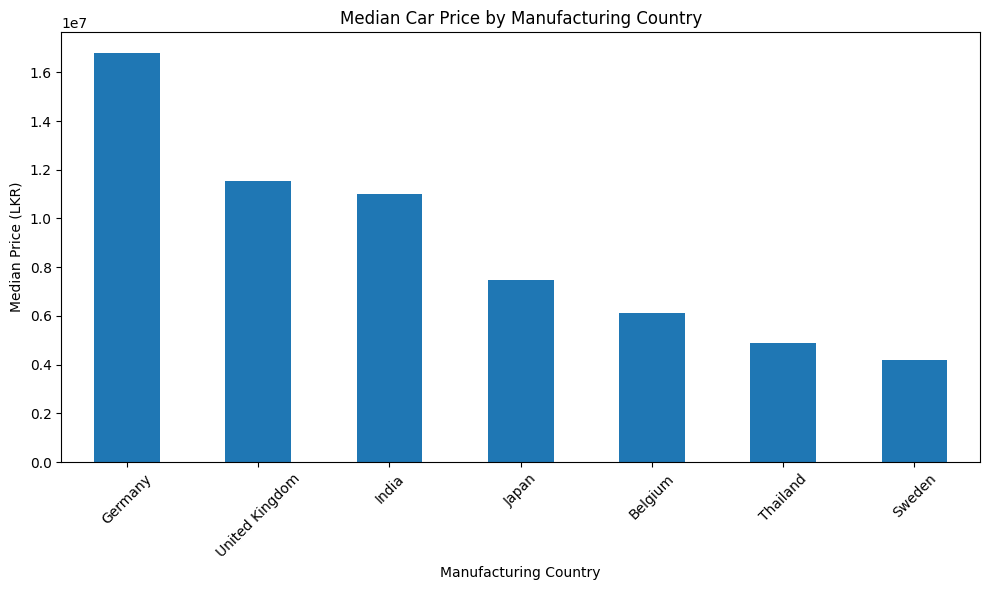

In [20]:
condition_price = (
    df.groupby('Manufacturing Country')['Price_numeric']
      .median()
      .sort_values(ascending=False)
)

plt.figure(figsize=(10, 6))

condition_price.plot(kind='bar')

plt.title('Median Car Price by Manufacturing Country')
plt.xlabel('Manufacturing Country')
plt.ylabel('Median Price (LKR)')
plt.xticks(rotation=45)
plt.savefig('fig/Mediancar price by Manufacturing Country')
plt.tight_layout()
plt.show()

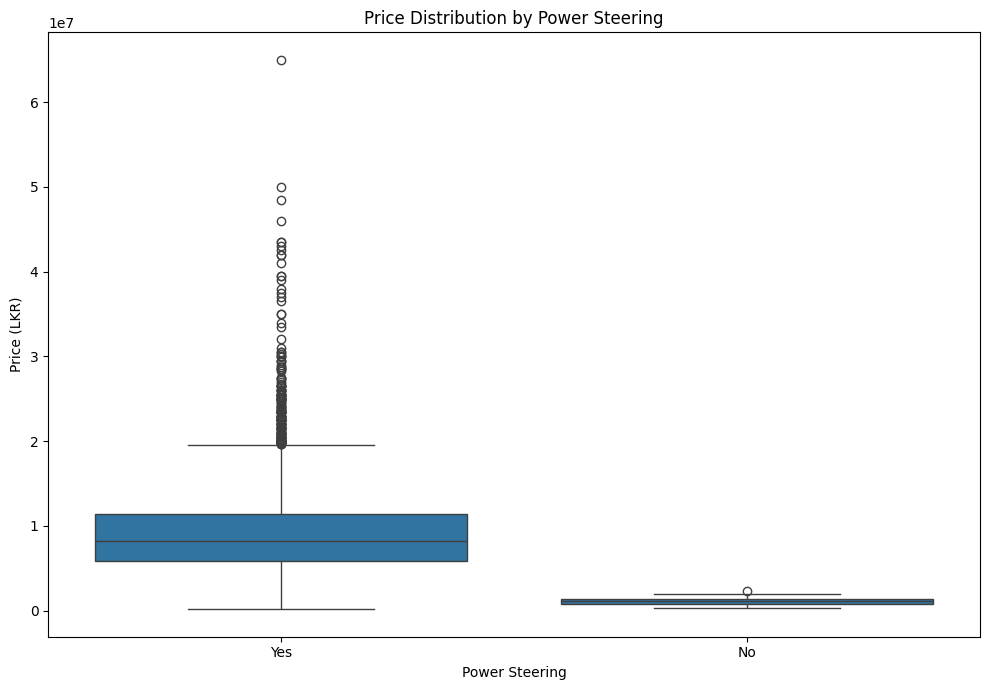

In [21]:
plt.figure(figsize=(10, 7))

sns.boxplot(
    data=df,
    x='Power Steering',
    y='Price_numeric'
)

plt.title('Price Distribution by Power Steering')
plt.xlabel('Power Steering')
plt.ylabel('Price (LKR)')
plt.tight_layout()
plt.savefig('fig/Price Distribution by Power Steering')
plt.show()

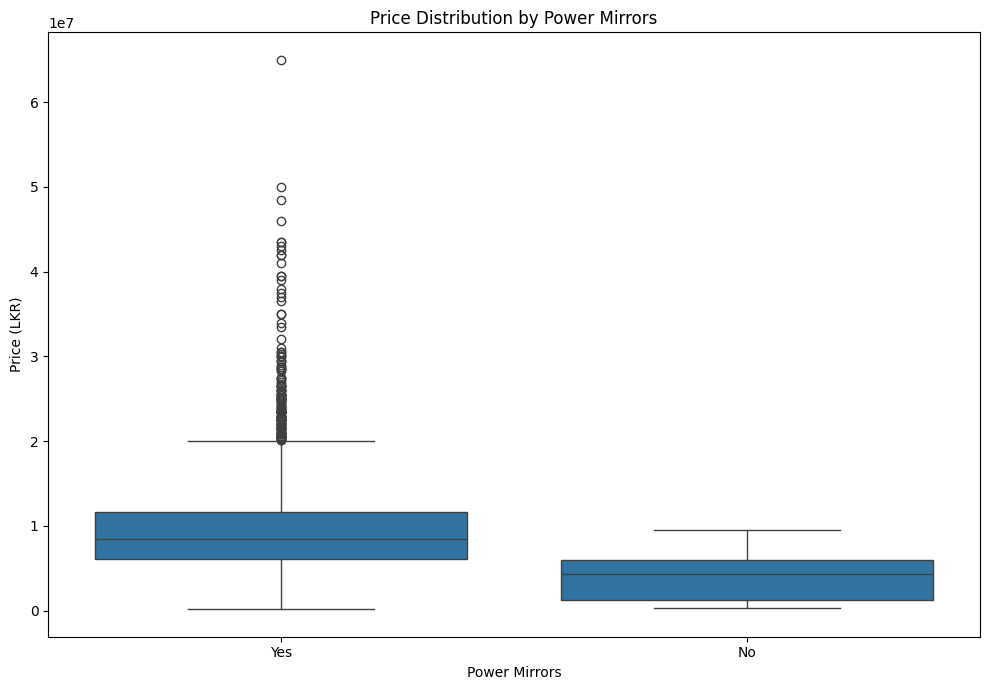

In [22]:
plt.figure(figsize=(10, 7))

sns.boxplot(
    data=df,
    x='Power Mirrors',
    y='Price_numeric'
)

plt.title('Price Distribution by Power Mirrors')
plt.xlabel('Power Mirrors')
plt.ylabel('Price (LKR)')
plt.tight_layout()
plt.savefig('fig/Price Distribution by Power Mirrors')
plt.show()

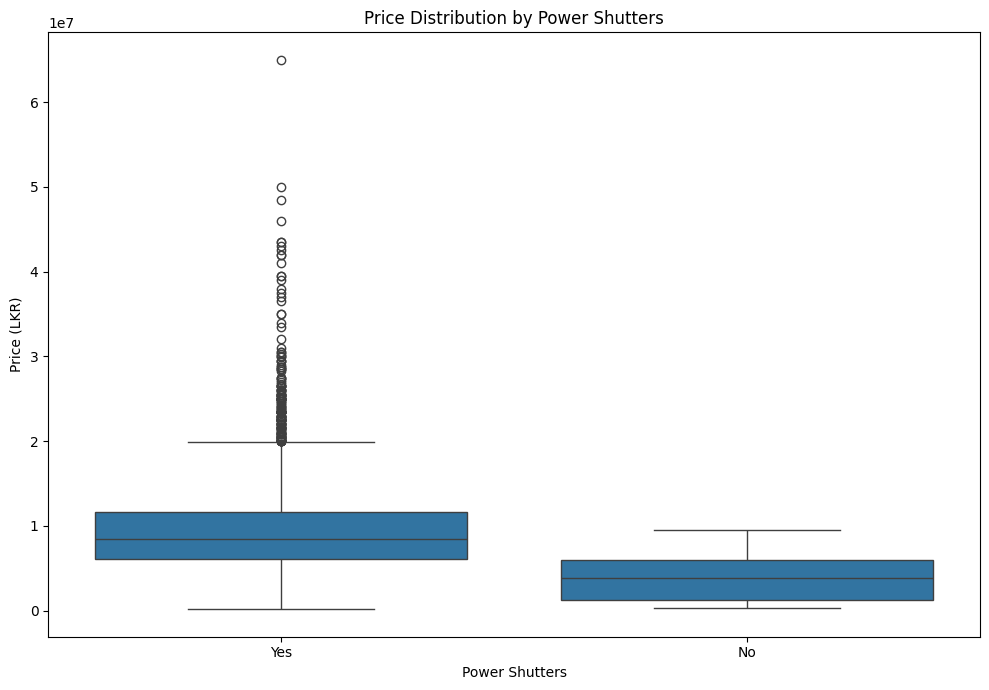

In [23]:
plt.figure(figsize=(10, 7))

sns.boxplot(
    data=df,
    x='Power Shutters',
    y='Price_numeric'
)

plt.title('Price Distribution by Power Shutters')
plt.xlabel('Power Shutters')
plt.ylabel('Price (LKR)')
plt.tight_layout()
plt.savefig('fig/Price Distribution by Power Shutters')
plt.show()

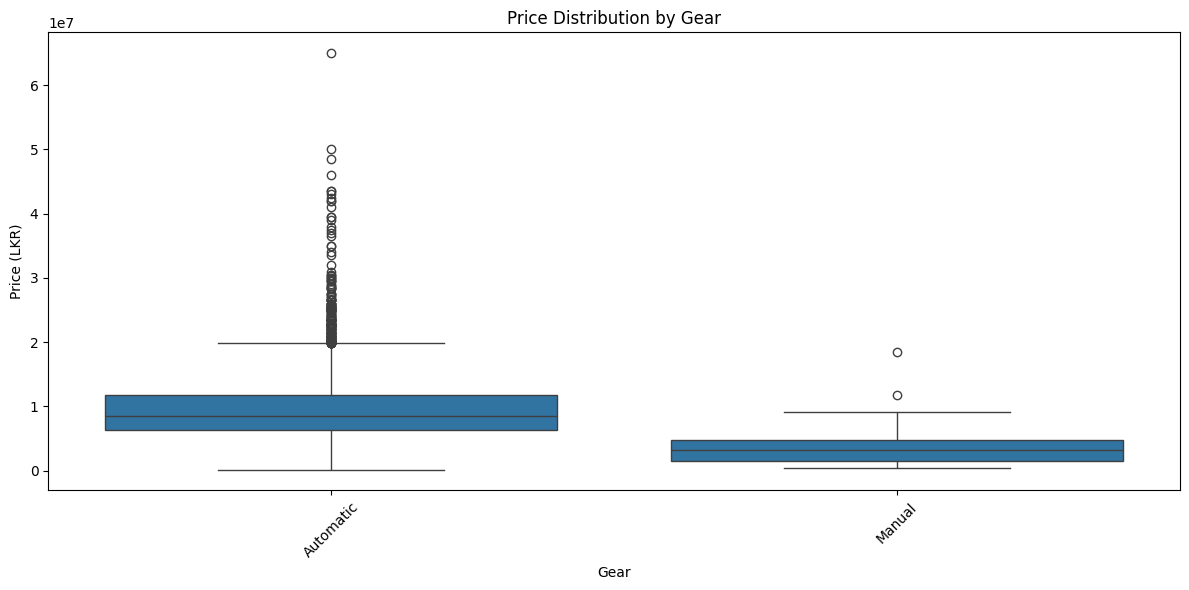

In [24]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df,
    x='Gear',
    y='Price_numeric'
)

plt.title('Price Distribution by Gear')
plt.xlabel('Gear')
plt.ylabel('Price (LKR)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('fig/Price Distribution by Gear')
plt.show()

C:\Users\savin\AppData\Local\Temp\ipykernel_24108\491255806.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Brand', y='Price_numeric', order=order, showfliers=False, palette='Set3')


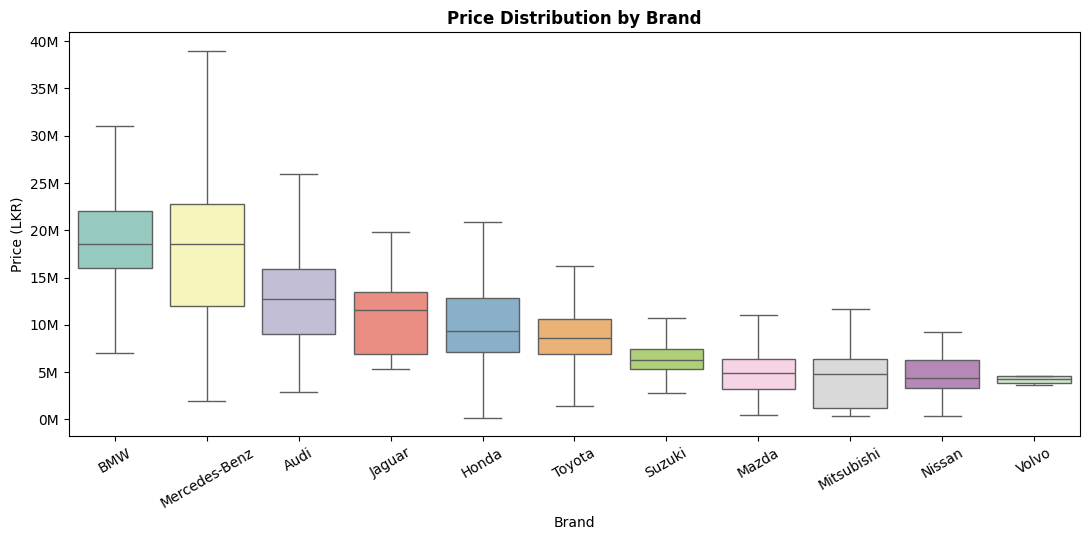

In [25]:
plt.figure(figsize=(11,5.5))
order = df.groupby('Brand')['Price_numeric'].median().sort_values(ascending=False).index
sns.boxplot(data=df, x='Brand', y='Price_numeric', order=order, showfliers=False, palette='Set3')
plt.title("Price Distribution by Brand", fontweight="bold")
plt.xlabel("Brand"); plt.ylabel("Price (LKR)")
plt.xticks(rotation=30)
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M'))
plt.tight_layout(); plt.savefig('fig/price_by_brand.png', dpi=150); plt.show()

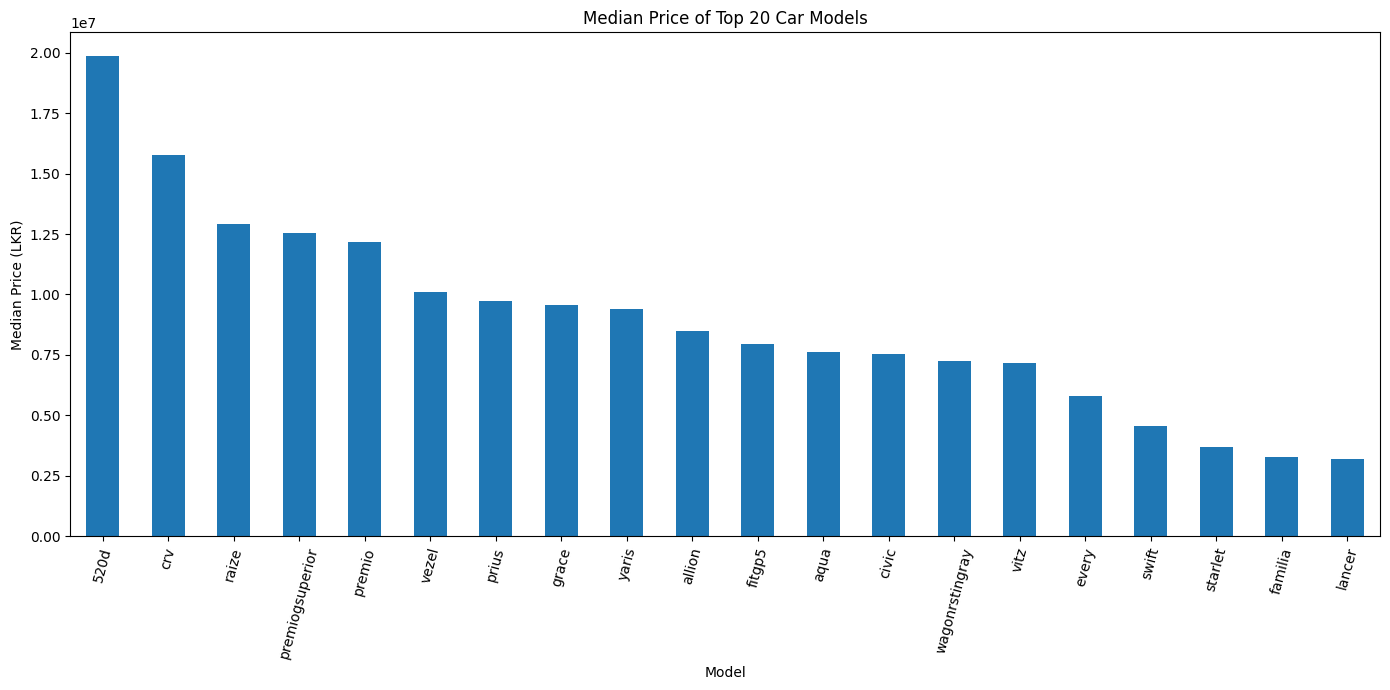

In [26]:
top_models = df['Model_cleaned'].value_counts().head(20).index
model_price = (
    df[df['Model_cleaned'].isin(top_models)]
    .groupby('Model_cleaned')['Price_numeric']
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(14, 7))
model_price.plot(kind='bar')

plt.title('Median Price of Top 20 Car Models')
plt.xlabel('Model')
plt.ylabel('Median Price (LKR)')
plt.xticks(rotation=75)
plt.tight_layout()
plt.savefig('fig/Median Price of Top 20 Car Models')
plt.show()

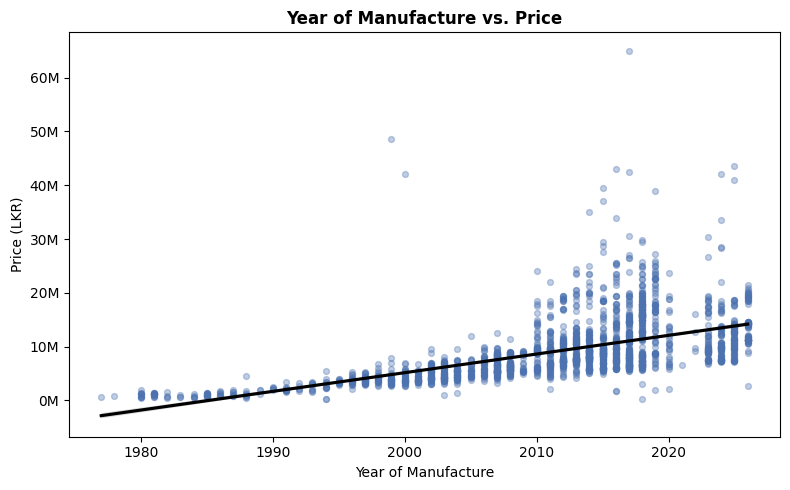

In [27]:
plt.figure(figsize=(8,5))
sns.regplot(data=df.sample(min(2500,len(df)), random_state=1), x='YOM', y='Price_numeric',
            scatter_kws={'alpha':0.35,'s':18,'color':'#4C72B0'}, line_kws={'color':'black'})
plt.title("Year of Manufacture vs. Price", fontweight="bold")
plt.xlabel("Year of Manufacture"); plt.ylabel("Price (LKR)")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M'))
plt.tight_layout(); plt.savefig('fig/yom_vs_price.png', dpi=150); plt.show()

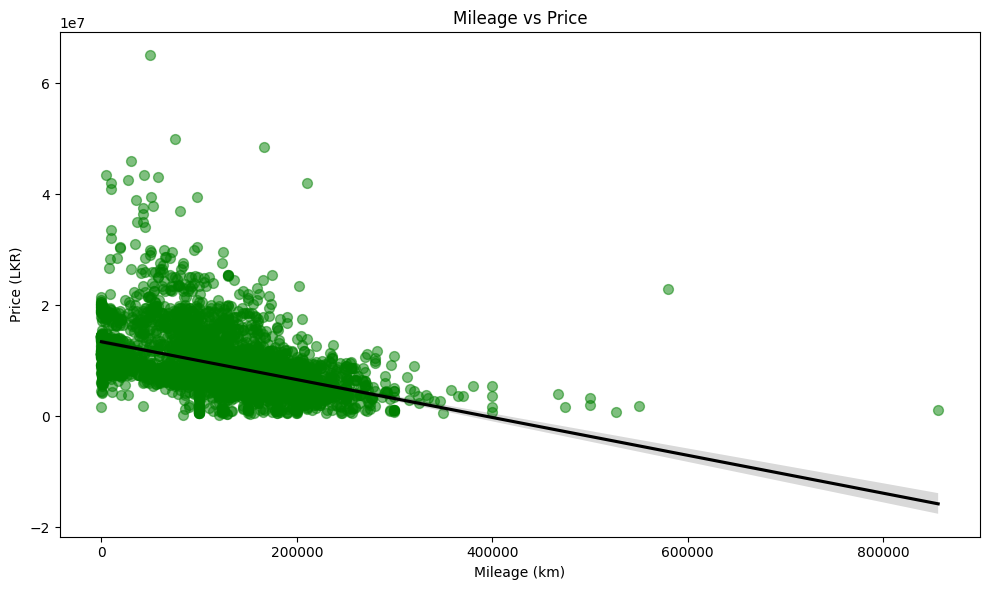

In [28]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='Mileage_numeric',
    y='Price_numeric',
    scatter_kws={'alpha': 0.5,'color': 'green', 's': 50},
    line_kws={'color': 'black'}
)

plt.title('Mileage vs Price')
plt.xlabel('Mileage (km)')
plt.ylabel('Price (LKR)')
plt.tight_layout()
plt.savefig('fig/Mileage vs Price')
plt.show()

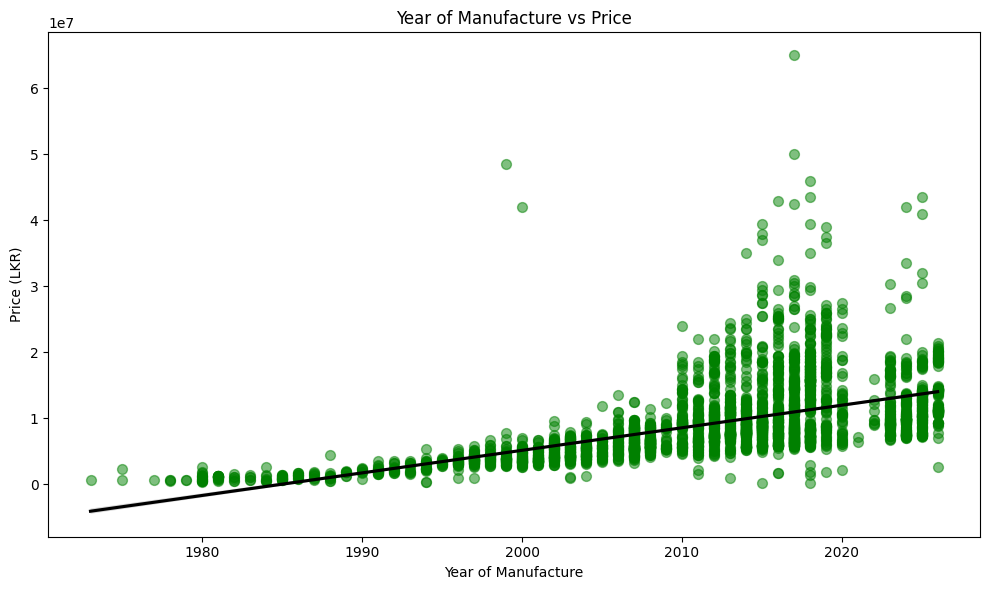

In [29]:
plt.figure(figsize=(10, 6))

sns.regplot(
    data=df,
    x='YOM',
    y='Price_numeric',
    scatter_kws={'alpha': 0.5,'color': 'green', 's': 50},
    line_kws={'color': 'black'}
)

plt.title('Year of Manufacture vs Price')
plt.xlabel('Year of Manufacture')
plt.ylabel('Price (LKR)')
plt.tight_layout()
plt.savefig('fig/Year of Manufacture vs Price')
plt.show()

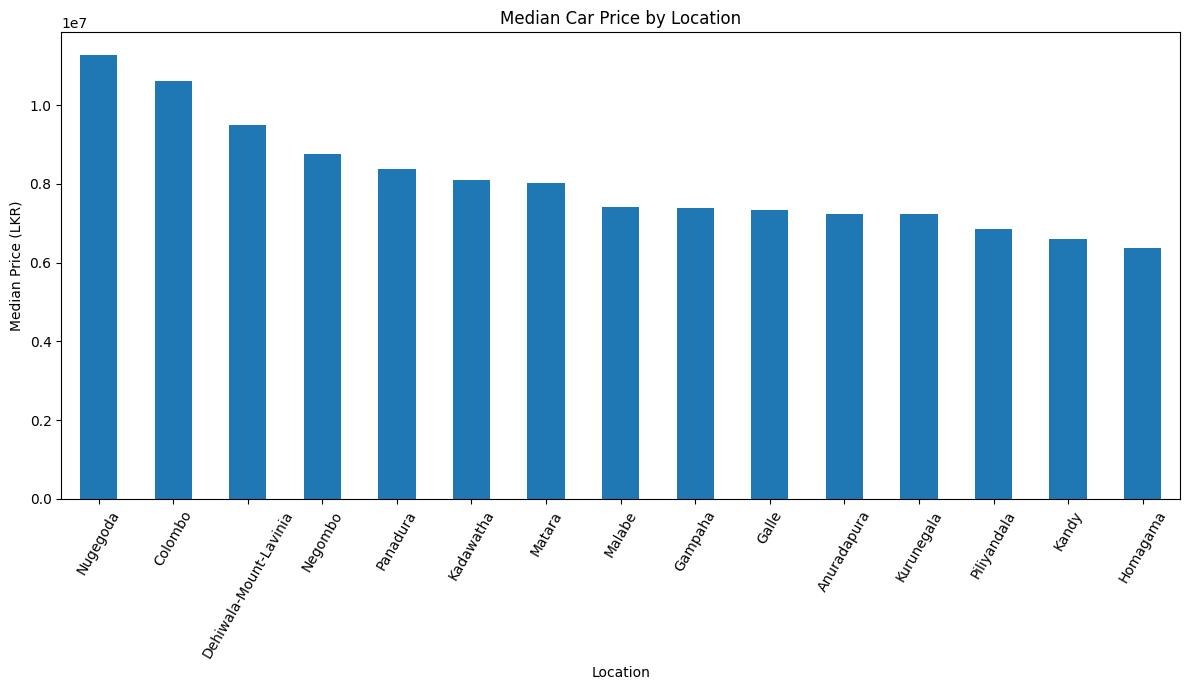

In [30]:
top_locations = df['Location'].value_counts().head(15).index
location_price = (
    df[df['Location'].isin(top_locations)]
    .groupby('Location')['Price_numeric']
    .median()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12, 7))

location_price.plot(kind='bar')

plt.title('Median Car Price by Location')
plt.xlabel('Location')
plt.ylabel('Median Price (LKR)')
plt.xticks(rotation=60)
plt.tight_layout()
plt.savefig('fig/Median Car Price by Location')
plt.show()

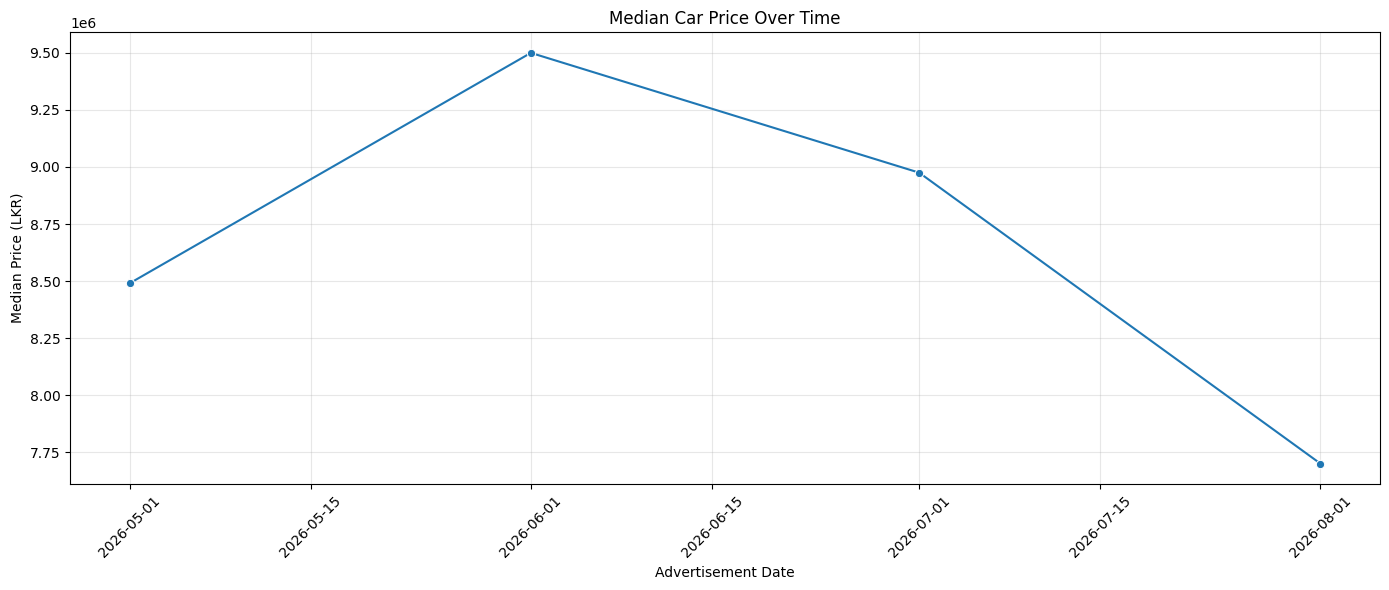

In [31]:
df['Ad_Date_clean_dt'] = pd.to_datetime(df['Ad_Date_clean'], errors='coerce')
df['Ad_Month'] = df['Ad_Date_clean_dt'].dt.to_period('M')

monthly_price = (
    df.groupby('Ad_Month')['Price_numeric']
      .median()
      .reset_index()
)

monthly_price['Ad_Month'] = monthly_price['Ad_Month'].dt.to_timestamp()

plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_price,
    x='Ad_Month',
    y='Price_numeric',
    marker='o'
)

plt.title('Median Car Price Over Time')
plt.xlabel('Advertisement Date')
plt.ylabel('Median Price (LKR)')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.savefig('fig/Median Car Price Over Time')
plt.tight_layout()
plt.show()

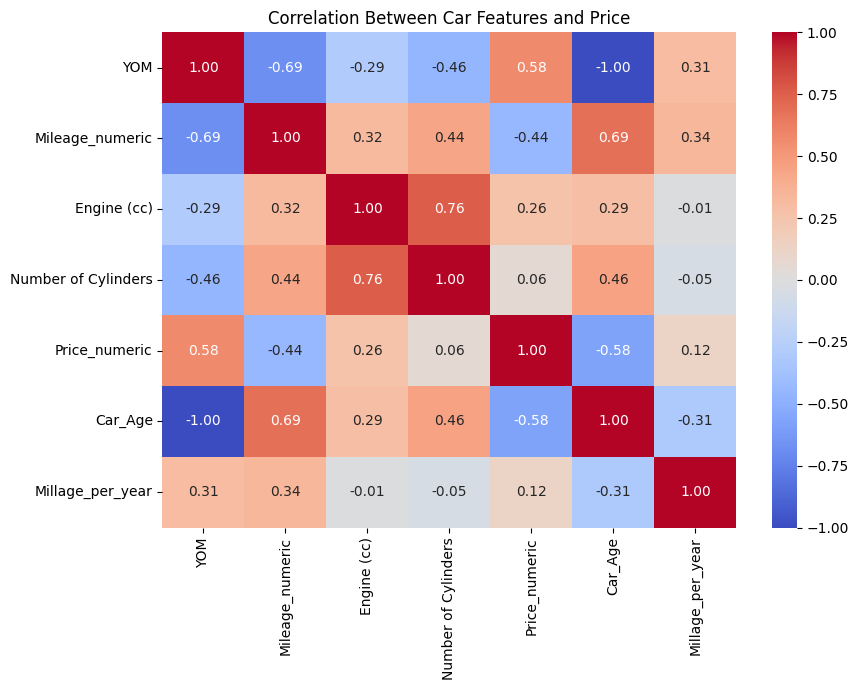

<Figure size 640x480 with 0 Axes>

In [32]:
numeric_cols = [
    'YOM',
    'Mileage_numeric',
    'Engine (cc)',
    'Number of Cylinders',
    'Price_numeric',
    'Car_Age',
    'Millage_per_year'


]

corr = df[numeric_cols].corr()

plt.figure(figsize=(9, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0
)

plt.title('Correlation Between Car Features and Price')
plt.tight_layout()
plt.figure('fig/Correlation Between Car Features and Price')
plt.show()

Model Building


In [33]:
for col in ["Power Steering", "Power Shutters", "Power Mirrors"]:
    df[col] = df[col].astype(str).str.strip().str.lower().map({"yes": 1, "no": 0}).fillna(0)

In [34]:
numeric_features = ["Car_Age", "Mileage_numeric", "Engine (cc)", "Number of Cylinders",
                     "Power Steering", "Power Shutters", "Power Mirrors"]
categorical_features = ["Brand", "Model_cleaned", "Gear", "Fuel Type", "Condition", "Body Type"]

X = df[numeric_features + categorical_features]
y_log = np.log1p(df["Price_numeric"])          # log-transform: price is heavily right-skewed


In [35]:
print(y_log)

0       16.482739
3       15.978834
4       16.066802
5       16.012735
7       15.919645
          ...    
6429    15.163584
6430    15.341567
6431    15.250595
6432    15.302781
6433    15.096445
Name: Price_numeric, Length: 4002, dtype: float64


In [36]:
X_train, X_test, y_train, y_test, price_train, price_test = train_test_split(
    X, y_log, df["Price_numeric"],
    test_size=0.2, random_state=42, stratify=df["strat_col"]
)
print(f"Train rows: {len(X_train)}, Test rows: {len(X_test)}")


Train rows: 3201, Test rows: 801


In [37]:
preprocessor = ColumnTransformer(transformers=[
    ("num", StandardScaler(), numeric_features),
    ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features),
])

In [38]:
linreg_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression(),)
])

In [39]:
linreg_model.fit(X_train, y_train)

,steps,"[('preprocessor', ...), ('regressor', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [40]:
y_pred = linreg_model.predict(X_train)

In [41]:
mae = mean_absolute_error(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred)
mape = mean_absolute_percentage_error(y_train, y_pred)
regression_accuracy = (1 - mape) * 100

print("Linear Regression Results")
print("-------------------------")
print(f"Regression Accuracy: {regression_accuracy:.2f}%")
print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

Linear Regression Results
-------------------------
Regression Accuracy: 99.39%
MAE  : 0.09
MSE  : 0.04
RMSE : 0.20
R²   : 0.9057


In [42]:
cv = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [43]:
sgd_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SGDRegressor(
        random_state=42,
        max_iter=5000,
        early_stopping=True
    ))
])

In [44]:
scoring = 'neg_root_mean_squared_error'
sgd_params = {
    'model__alpha': [0.00001, 0.0001, 0.001, 0.01],
    'model__eta0': [0.001, 0.01, 0.1],
    'model__learning_rate': ['invscaling', 'adaptive']
}

sgd_grid = GridSearchCV(
    sgd_pipeline,
    sgd_params,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

sgd_grid.fit(X_train, y_train)

,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__alpha': [1e-05, 0.0001, ...], 'model__eta0': [0.001, 0.01, ...], 'model__learning_rate': ['invscaling', 'adaptive']}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [45]:
print("Best SGD Parameters:")
print(sgd_grid.best_params_)


Best SGD Parameters:
{'model__alpha': 1e-05, 'model__eta0': 0.01, 'model__learning_rate': 'adaptive'}


In [46]:
y_pred = sgd_grid.predict(X_train)

In [47]:
mae = mean_absolute_error(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred)
mape = mean_absolute_percentage_error(y_train, y_pred)
regression_accuracy = (1 - mape) * 100

print("SGD Regression Results")
print("-------------------------")
print(f"Regression Accuracy: {regression_accuracy:.2f}%")
print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

SGD Regression Results
-------------------------
Regression Accuracy: 99.31%
MAE  : 0.11
MSE  : 0.05
RMSE : 0.21
R²   : 0.8928


In [48]:
lasso_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Lasso(
        max_iter=20000,
        random_state=42
    ))
])

In [49]:
lasso_params = {
    'model__alpha': [
        0.0001,
        0.001,
        0.01,
        0.1,
        1,
        10
    ]
}

In [50]:
lasso_grid = GridSearchCV(
    lasso_pipeline,
    lasso_params,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

print("Best Lasso Parameters:")
print(lasso_grid.best_params_)


Best Lasso Parameters:
{'model__alpha': 0.0001}


In [51]:
y_pred = lasso_grid.predict(X_train)
mae = mean_absolute_error(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred)
mape = mean_absolute_percentage_error(y_train, y_pred)
regression_accuracy = (1 - mape) * 100

print("Lasso Regression Results")
print("-------------------------")
print(f"Regression Accuracy: {regression_accuracy:.2f}%")
print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

Lasso Regression Results
-------------------------
Regression Accuracy: 99.35%
MAE  : 0.10
MSE  : 0.04
RMSE : 0.20
R²   : 0.9019


In [52]:
ridge_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge())
])

ridge_params = {
    'model__alpha': [
        0.01,
        0.1,
        1,
        10,
        50,
        100,
        1000
    ]
}

In [53]:
ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_params,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

ridge_grid.fit(X_train, y_train)

print("Best Ridge Parameters:")
print(ridge_grid.best_params_)

Best Ridge Parameters:
{'model__alpha': 1}


In [54]:
y_pred = ridge_grid.predict(X_train)
mae = mean_absolute_error(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred)
mape = mean_absolute_percentage_error(y_train, y_pred)
regression_accuracy = (1 - mape) * 100

print("ridge Regression Results")
print("-------------------------")
print(f"Regression Accuracy: {regression_accuracy:.2f}%")
print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

ridge Regression Results
-------------------------
Regression Accuracy: 99.38%
MAE  : 0.10
MSE  : 0.04
RMSE : 0.20
R²   : 0.9039


In [55]:
print("Best CV RMSE:",
      -ridge_grid.best_score_)

Best CV RMSE: 0.21998766928303687


In [56]:
poly_numeric_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('poly', PolynomialFeatures(
        include_bias=False
    ))
])

poly_preprocessor = ColumnTransformer(
    transformers=[
        ('num', poly_numeric_pipeline, numeric_cols),
        ('cat',OneHotEncoder(handle_unknown="ignore", sparse_output=False) , categorical_features)
    ],
    remainder='passthrough'
)

poly_pipeline = Pipeline([
    ('preprocessor', poly_preprocessor),
    ('model', Ridge())
])

poly_params = {
    'preprocessor__num__poly__degree': [2, 3],
    'model__alpha': [0.1, 1, 10, 100]
}

In [59]:
tree_preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown="ignore", sparse_output=False), categorical_features)
    ],
    remainder='passthrough'
)

tree_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', DecisionTreeRegressor(
        random_state=42
    ))
])

tree_params = {
    'model__max_depth': [
        5,
        10,
        15,
        20,
        None
    ],
    'model__min_samples_split': [
        2,
        5,
        10,
        20
    ],
    'model__min_samples_leaf': [
        1,
        2,
        5,
        10
    ],
    'model__max_features': [
        None,
        'sqrt',
        'log2'
    ]
}

In [60]:
tree_grid = GridSearchCV(
    tree_pipeline,
    tree_params,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

tree_grid.fit(X_train, y_train)

print("Best Decision Tree Parameters:")
print(tree_grid.best_params_)

print("Best CV RMSE:",
      -tree_grid.best_score_)

Best Decision Tree Parameters:
{'model__max_depth': 20, 'model__max_features': None, 'model__min_samples_leaf': 5, 'model__min_samples_split': 20}
Best CV RMSE: 0.23746408710905592


In [61]:
y_pred = tree_grid.predict(X_train)
mae = mean_absolute_error(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred)
mape = mean_absolute_percentage_error(y_train, y_pred)
regression_accuracy = (1 - mape) * 100

print("tree Regression Results")
print("-------------------------")
print(f"Regression Accuracy: {regression_accuracy:.2f}%")
print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

tree Regression Results
-------------------------
Regression Accuracy: 99.44%
MAE  : 0.09
MSE  : 0.04
RMSE : 0.19
R²   : 0.9152


In [62]:
RF_params = {
    'model__n_estimators': [200,300,400],
    'model__max_depth': [None, 15, 25, 35],
    'model__min_samples_leaf': [1, 2, 4],
    'model__max_features': [
        None,
        0.5,
        'sqrt',
        'log2'
    ]
}

RF_pipeline = Pipeline([
    ('preprocessor', tree_preprocessor),
    ('model', RandomForestRegressor(
        random_state=42
    ))
])

RF_grid = GridSearchCV(
    RF_pipeline,
    RF_params,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

RF_grid.fit(X_train, y_train)

print("Best Decision Tree Parameters:")
print(tree_grid.best_params_)

print("Best CV RMSE:",
      -tree_grid.best_score_)

Best Decision Tree Parameters:
{'model__max_depth': 20, 'model__max_features': None, 'model__min_samples_leaf': 5, 'model__min_samples_split': 20}
Best CV RMSE: 0.23746408710905592


In [63]:
y_pred = RF_grid.predict(X_train)
mae = mean_absolute_error(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred)
mape = mean_absolute_percentage_error(y_train, y_pred)
regression_accuracy = (1 - mape) * 100

print("RF Regression Results")
print("-------------------------")
print(f"Regression Accuracy: {regression_accuracy:.2f}%")
print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

RF Regression Results
-------------------------
Regression Accuracy: 99.63%
MAE  : 0.06
MSE  : 0.02
RMSE : 0.15
R²   : 0.9480


In [64]:
svr_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', SVR())
])

svr_params = {
    'model__kernel': ['rbf'],
    'model__C': [
        10,
        100,
        1000
    ],
    'model__gamma': [
        'scale',
        0.001,
        0.01,
        0.1
    ],
    'model__epsilon': [
        0.01,
        0.1,
        0.5
    ]
}

In [65]:
svr_grid = GridSearchCV(
    svr_pipeline,
    svr_params,
    cv=cv,
    scoring=scoring,
    n_jobs=-1
)

svr_grid.fit(X_train, y_train)

print("Best SVR Parameters:")
print(svr_grid.best_params_)

print("Best CV RMSE:",
      -svr_grid.best_score_)


Best SVR Parameters:
{'model__C': 10, 'model__epsilon': 0.01, 'model__gamma': 0.01, 'model__kernel': 'rbf'}
Best CV RMSE: 0.20506540561225045


In [66]:
y_pred = svr_grid.predict(X_train)
mae = mean_absolute_error(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred)
mape = mean_absolute_percentage_error(y_train, y_pred)
regression_accuracy = (1 - mape) * 100

print("support bvector Regression Results")
print("-------------------------")
print(f"Regression Accuracy: {regression_accuracy:.2f}%")
print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

support bvector Regression Results
-------------------------
Regression Accuracy: 99.54%
MAE  : 0.07
MSE  : 0.04
RMSE : 0.20
R²   : 0.9089


In [67]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ))
])

xgb_params = {
    'model__n_estimators': [200, 300,500,700],
    
    'model__max_depth': [3,4, 5,6],
    
    'model__learning_rate': [
        0.01,
        0.03,
        0.05,
        0.1
    ],
    
    'model__subsample': [
        0.7,
        0.8,
        1.0
    ],
    
    'model__colsample_bytree': [
        0.7,
        0.8,
        1.0
    ],
    
    'model__min_child_weight': [
        1,
        3,
        5
    ]
}


In [68]:
xgb_grid = GridSearchCV(
    estimator=xgb_pipeline,
    param_grid=xgb_params,
    scoring=scoring,
    cv=cv,
    n_jobs=-1,
    verbose=1
)

xgb_grid.fit(X_train, y_train)

Fitting 5 folds for each of 1728 candidates, totalling 8640 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__colsample_bytree': [0.7, 0.8, ...], 'model__learning_rate': [0.01, 0.03, ...], 'model__max_depth': [3, 4, ...], 'model__min_child_weight': [1, 3, ...], ...}"
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,KFold(n_split... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('num', ...), ('cat', ...)]"


In [69]:
y_pred = xgb_grid.predict(X_train)
mae = mean_absolute_error(y_train, y_pred)
mse = mean_squared_error(y_train, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_train, y_pred)
mape = mean_absolute_percentage_error(y_train, y_pred)
regression_accuracy = (1 - mape) * 100

print("XGB Regression Results")
print("-------------------------")
print(f"Regression Accuracy: {regression_accuracy:.2f}%")
print(f"MAE  : {mae:,.2f}")
print(f"MSE  : {mse:,.2f}")
print(f"RMSE : {rmse:,.2f}")
print(f"R²   : {r2:.4f}")

XGB Regression Results
-------------------------
Regression Accuracy: 99.47%
MAE  : 0.08
MSE  : 0.03
RMSE : 0.18
R²   : 0.9228


In [88]:
models = {
    'XGB regression': xgb_grid.best_estimator_, 
    'Linear Regression': linreg_model,
    'SGD Regression': sgd_grid.best_estimator_,
    'Lasso Regression': lasso_grid.best_estimator_,
    'Ridge Regression': ridge_grid.best_estimator_,
    'Decision Tree': tree_grid.best_estimator_,
    'Random Forest': RF_grid.best_estimator_,
    'SVR': svr_grid.best_estimator_
}

# Test Accuracy

In [94]:
results = []

for name, model in models.items():

    y_pred = model.predict(X_test)

    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    mse = mean_squared_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_test,
        y_pred
    )
    mape = mean_absolute_percentage_error(y_test, y_pred)
    regression_accuracy = (1 - mape) * 100

    results.append({
        'Model': name,
        'Accuracy': f"{regression_accuracy:.2f}%",
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

test_results_df = pd.DataFrame(results)

test_results_df = test_results_df.sort_values(
    'RMSE'
)



print(test_results_df)

               Model Accuracy       MAE       MSE      RMSE        R2
6      Random Forest   99.51%  0.076050  0.020158  0.141980  0.947848
0     XGB regression   99.45%  0.085152  0.020927  0.144662  0.945859
7                SVR   99.51%  0.076032  0.021328  0.146039  0.944824
1  Linear Regression   99.39%  0.095506  0.024761  0.157355  0.935942
4   Ridge Regression   99.38%  0.097234  0.025143  0.158564  0.934953
3   Lasso Regression   99.36%  0.100738  0.026179  0.161799  0.932273
2     SGD Regression   99.31%  0.107455  0.030281  0.174013  0.921661
5      Decision Tree   99.37%  0.099326  0.031630  0.177850  0.918169


# Train Accuracy


In [92]:
results = []

for name, model in models.items():

    y_pred = model.predict(X_train)

    mae = mean_absolute_error(
        y_train,
        y_pred
    )

    mse = mean_squared_error(
        y_train,
        y_pred
    )

    rmse = np.sqrt(mse)

    r2 = r2_score(
        y_train,
        y_pred
    )
    mape = mean_absolute_percentage_error(y_train, y_pred)
    regression_accuracy = (1 - mape) * 100

    results.append({
        'Model': name,
        'Accuracy': f"{regression_accuracy:.2f}%",
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    'RMSE'
)



print(results_df)

               Model Accuracy       MAE       MSE      RMSE        R2
6      Random Forest   99.63%  0.057360  0.022093  0.148637  0.947994
0     XGB regression   99.47%  0.082387  0.032809  0.181133  0.922768
5      Decision Tree   99.44%  0.086476  0.036022  0.189794  0.915206
7                SVR   99.54%  0.070466  0.038695  0.196711  0.908913
1  Linear Regression   99.39%  0.093767  0.040068  0.200171  0.905681
4   Ridge Regression   99.38%  0.096031  0.040807  0.202007  0.903943
3   Lasso Regression   99.35%  0.100731  0.041684  0.204165  0.901878
2     SGD Regression   99.31%  0.107768  0.045557  0.213440  0.892761


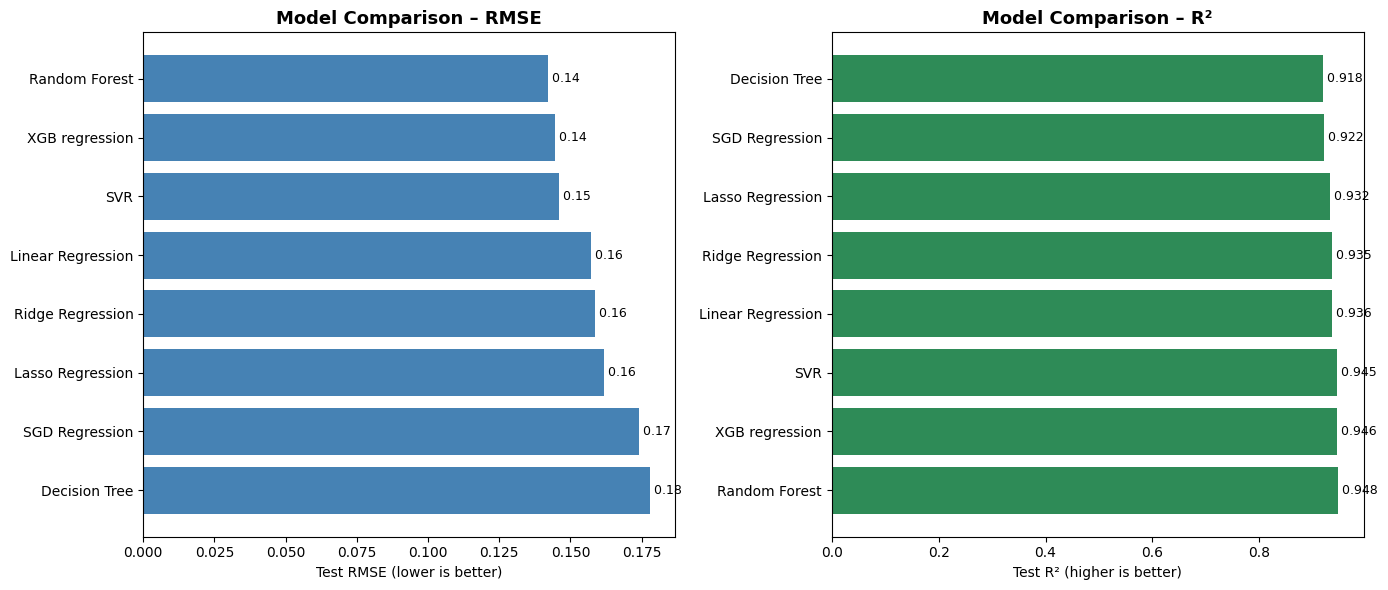

In [95]:
import matplotlib.pyplot as plt

# -----------------------------------------
# 1. Sort data for each metric
# -----------------------------------------

# RMSE: lower is better
rmse_df = test_results_df.sort_values('RMSE', ascending=True)

# R2: higher is better
r2_df = test_results_df.sort_values('R2', ascending=True)


# -----------------------------------------
# 2. Create two side-by-side plots
# -----------------------------------------

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


# =========================================
# LEFT PLOT - RMSE
# =========================================

axes[0].barh(
    rmse_df['Model'],
    rmse_df['RMSE'],
    color='steelblue'
)

axes[0].set_title('Model Comparison – RMSE', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Test RMSE (lower is better)')
axes[0].set_ylabel('')

# Put best model at the top
axes[0].invert_yaxis()

# Add RMSE values to bars
for i, value in enumerate(rmse_df['RMSE']):
    axes[0].text(
        value,
        i,
        f' {value:.2f}',
        va='center',
        fontsize=9
    )


# =========================================
# RIGHT PLOT - R²
# =========================================

axes[1].barh(
    r2_df['Model'],
    r2_df['R2'],
    color='seagreen'
)

axes[1].set_title('Model Comparison – R²', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Test R² (higher is better)')
axes[1].set_ylabel('')

# Put best model at the top
axes[1].invert_yaxis()

# Add R² values to bars
for i, value in enumerate(r2_df['R2']):
    axes[1].text(
        value,
        i,
        f' {value:.3f}',
        va='center',
        fontsize=9
    )


# -----------------------------------------
# 3. Improve layout
# -----------------------------------------

plt.tight_layout()
plt.show()

## Save Random Forest Model as Pickel


In [73]:
# import joblib

# # Save the trained model to a file
# joblib.dump(RF_grid.best_estimator_, 'Model.pkl')

In [74]:
# Pick the winning model straight from the leaderboard you already built
best_model_name = results_df.sort_values('RMSE').iloc[0]['Model']
best_model = models[best_model_name]
print(f"Explaining best model: {best_model_name}")

# Every pipeline here is [preprocessor_step, estimator_step] regardless of what the
# steps are named ('model' vs 'regressor'), so grab them positionally.
preprocessor_step = best_model.steps[0][1]
estimator_step = best_model.steps[-1][1]
print(f"Preprocessor: {preprocessor_step}")
print(f"Estimator: {estimator_step}")

Explaining best model: Random Forest
Preprocessor: ColumnTransformer(remainder='passthrough',
                  transformers=[('cat',
                                 OneHotEncoder(handle_unknown='ignore',
                                               sparse_output=False),
                                 ['Brand', 'Model_cleaned', 'Gear', 'Fuel Type',
                                  'Condition', 'Body Type'])])
Estimator: RandomForestRegressor(max_depth=25, max_features=0.5, min_samples_leaf=2,
                      n_estimators=400, random_state=42)


In [75]:
# Transform features through this model's own preprocessor so we explain in the
# exact numeric space the estimator actually sees (scaled numeric + one-hot cats).
feature_names = preprocessor_step.get_feature_names_out()

# Background = a small reference sample (used by Linear/Kernel/Permutation explainers)
# Explain set = the sample we actually compute SHAP values for
rng = np.random.RandomState(42)
bg_idx = rng.choice(X_train.index, size=min(100, len(X_train)), replace=False)
explain_idx = rng.choice(X_test.index, size=min(200, len(X_test)), replace=False)

X_train_bg = pd.DataFrame(
    preprocessor_step.transform(X_train.loc[bg_idx]),
    columns=feature_names, index=bg_idx
)
X_test_explain = pd.DataFrame(
    preprocessor_step.transform(X_test.loc[explain_idx]),
    columns=feature_names, index=explain_idx
)

print(f"Background rows: {len(X_train_bg)}, explain rows: {len(X_test_explain)}, features: {len(feature_names)}")

Background rows: 100, explain rows: 200, features: 280


In [76]:
# Cascade to the fastest exact explainer that fits the winning model; fall back to a
# model-agnostic explainer (slower, so we keep the sample sizes above small) otherwise.
try:
    explainer = shap.TreeExplainer(estimator_step)
    shap_values = explainer(X_test_explain)
    print("Used TreeExplainer")
except Exception as e_tree:
    try:
        explainer = shap.LinearExplainer(estimator_step, X_train_bg)
        shap_values = explainer(X_test_explain)
        print("Used LinearExplainer")
    except Exception as e_lin:
        explainer = shap.Explainer(estimator_step.predict, X_train_bg)
        shap_values = explainer(X_test_explain)
        print("Used model-agnostic Explainer (Permutation/Kernel) — slower, sample-based")

Used TreeExplainer


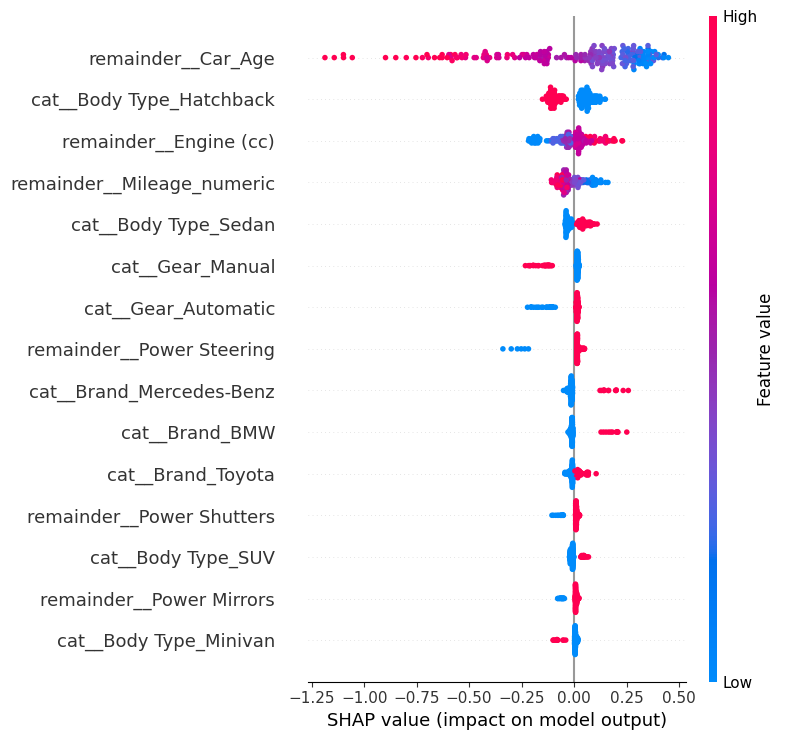

In [77]:
# Beeswarm: direction + magnitude of each feature's effect across the sample
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_explain, show=False, max_display=15)
plt.tight_layout()
plt.savefig('fig/shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

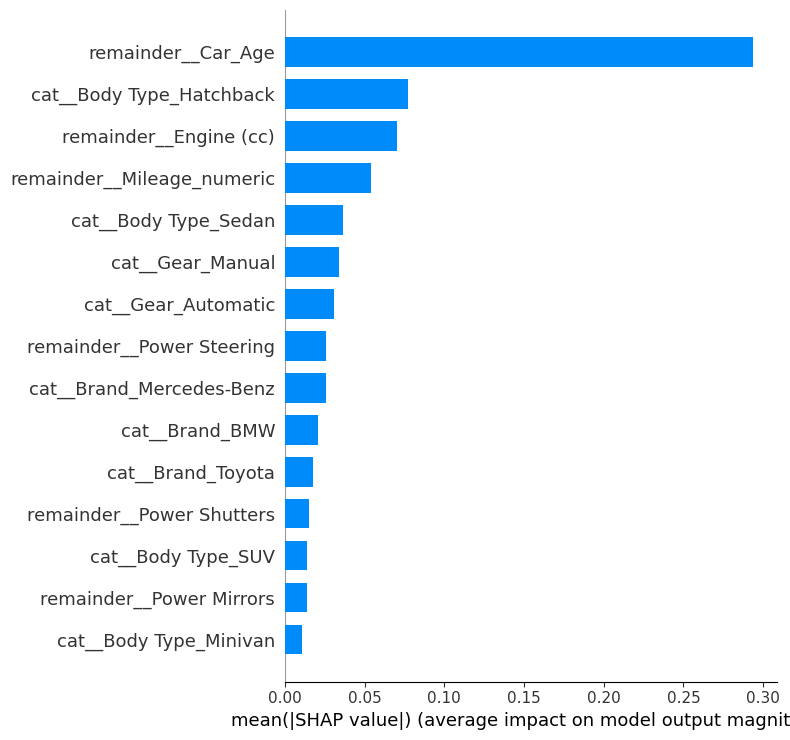

In [78]:
# Bar chart: mean |SHAP value| per feature — a clean global importance ranking
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test_explain, plot_type='bar', show=False, max_display=15)
plt.tight_layout()
plt.savefig('fig/shap_importance_bar.png', dpi=150, bbox_inches='tight')
plt.show()

Row: 1598
Predicted price: Rs. 19,534,324
Actual price   : Rs. 20,600,000


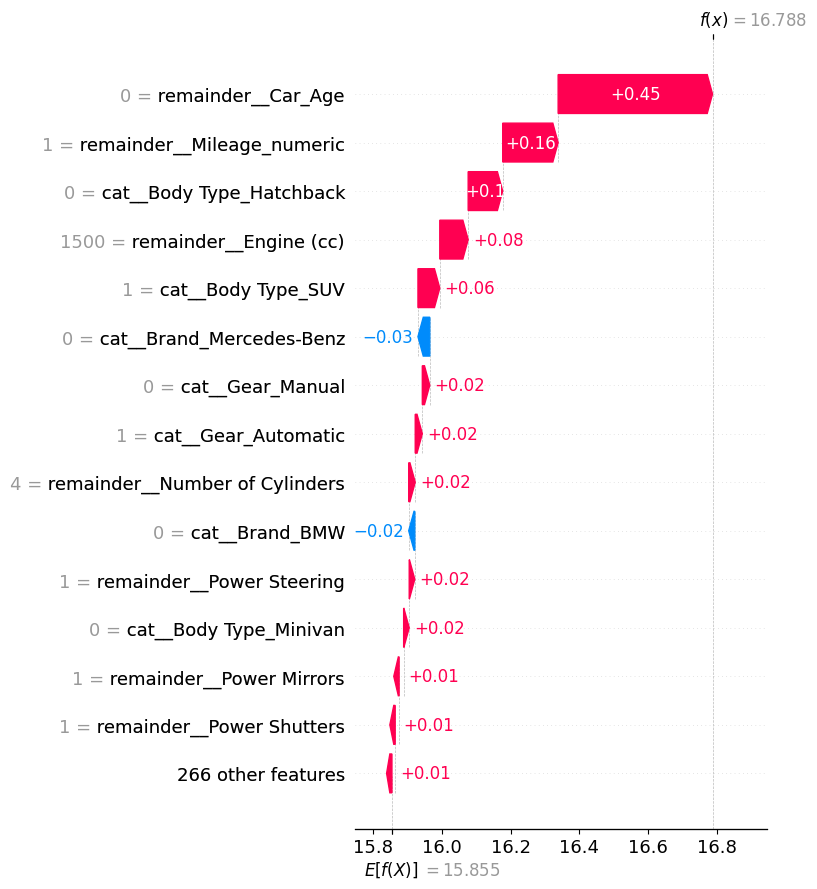

In [79]:
# Pick one test-set listing to explain in detail
local_i = 0
local_row_idx = X_test_explain.index[local_i]

pred_log = best_model.predict(X_test.loc[[local_row_idx]])[0]
actual_log = y_test.loc[local_row_idx]
print(f"Row: {local_row_idx}")
print(f"Predicted price: Rs. {np.expm1(pred_log):,.0f}")
print(f"Actual price   : Rs. {np.expm1(actual_log):,.0f}")

plt.figure(figsize=(10, 8))
shap.plots.waterfall(shap_values[local_i], max_display=15, show=False)
plt.tight_layout()
plt.savefig('fig/shap_waterfall_example.png', dpi=150, bbox_inches='tight')
plt.show()

In [80]:
# Label-encode categorical columns just for LIME's internal sampling; predict_fn below
# decodes them back to the original strings before calling the real pipeline.
cat_maps = {}
X_encoded = X.copy()
for col in categorical_features:
    codes, uniques = pd.factorize(X[col])
    X_encoded[col] = codes
    cat_maps[col] = uniques.tolist()

X_train_enc = X_encoded.loc[X_train.index]
X_test_enc = X_encoded.loc[X_test.index]

categorical_indices = [X.columns.get_loc(c) for c in categorical_features]
categorical_names = {i: cat_maps[X.columns[i]] for i in categorical_indices}

def lime_predict_fn(data_2d):
    """LIME calls this with perturbed rows in X's column order. Decode categorical
    integer codes back to labels, then run the actual fitted pipeline (preprocessing
    + model) so LIME is explaining the real model, not a proxy."""
    df_batch = pd.DataFrame(data_2d, columns=X.columns)
    for col in numeric_features:
        df_batch[col] = df_batch[col].astype(float)
    for col in categorical_features:
        n_cats = len(cat_maps[col])
        codes = df_batch[col].round().astype(int).clip(0, n_cats - 1)
        df_batch[col] = [cat_maps[col][c] for c in codes]
    return best_model.predict(df_batch)

lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train_enc.values,
    feature_names=list(X.columns),
    categorical_features=categorical_indices,
    categorical_names=categorical_names,
    mode='regression',
    discretize_continuous=True,
    random_state=42
)

LIME local explanation for row 1598 (predicted log-price):
  Car_Age <= 8.00                          +0.5033
  Gear=Automatic                           +0.1775
  Mileage_numeric <= 79000.00              +0.0866
  1490.00 < Engine (cc) <= 1500.00         +0.0687
  Body Type=SUV                            +0.0441
  Brand=Honda                              -0.0317
  Condition=Unregistered (Recondition)     +0.0214
  Model_cleaned=vezelzplay                 +0.0119
  Fuel Type=Hybrid                         +0.0119
  3.00 < Number of Cylinders <= 4.00       +0.0066


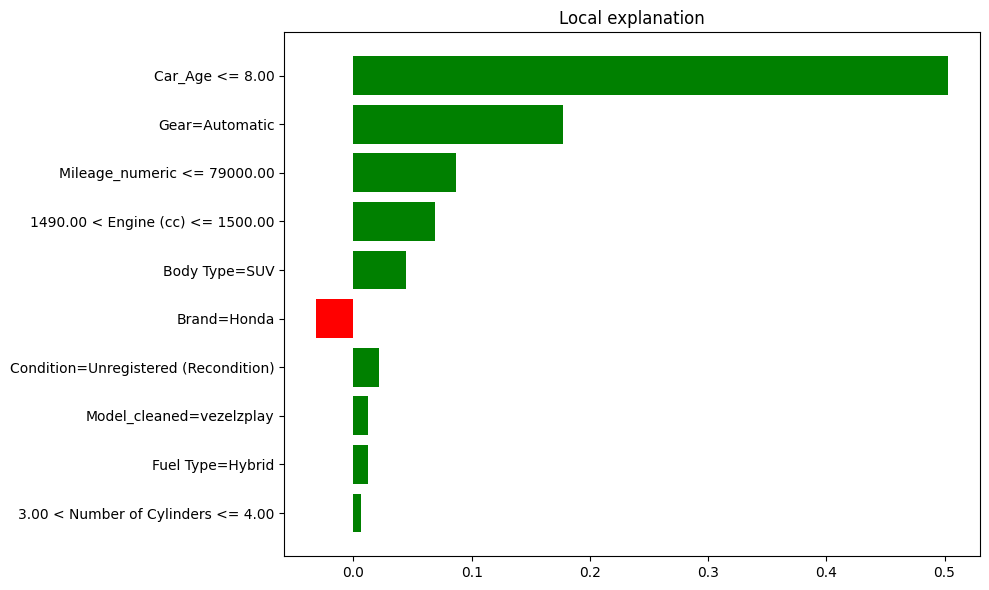

In [81]:
# Explain the SAME row we used for the SHAP waterfall plot, for a direct comparison
lime_row_idx = local_row_idx
lime_exp = lime_explainer.explain_instance(
    X_test_enc.loc[lime_row_idx].values,
    lime_predict_fn,
    num_features=10
)

print(f"LIME local explanation for row {lime_row_idx} (predicted log-price):")
for feature_desc, weight in lime_exp.as_list():
    print(f"  {feature_desc:40s} {weight:+.4f}")

fig = lime_exp.as_pyplot_figure()
fig.set_size_inches(10, 6)
plt.tight_layout()
plt.savefig('fig/lime_local_example.png', dpi=150, bbox_inches='tight')
plt.show()

                Feature  Mean |LIME weight|   n
13              Car_Age            0.652292  22
19                 8.00            0.295814   5
0             Body Type            0.162148  40
1                  Gear            0.150117  40
16          Engine (cc)            0.143857  18
5         Model_cleaned            0.090702  40
17      Mileage_numeric            0.075390  18
14              1490.00            0.049442  10
3             Condition            0.047823  40
4               1000.00            0.046897  12
9                 Brand            0.046382  40
7             128000.00            0.036880  10
15             79000.00            0.032378  12
18  Number of Cylinders            0.031723  11
2             Fuel Type            0.029040  40
8                 12.00            0.025087  13
6                  3.00            0.021930  29
10       Power Steering            0.000000  40
11       Power Shutters            0.000000  40
12        Power Mirrors            0.000

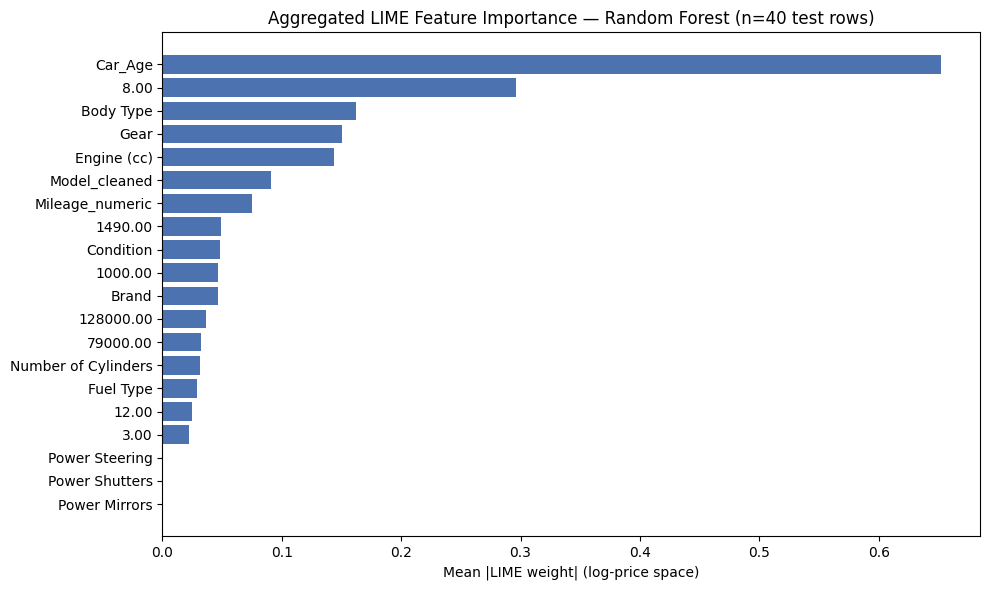

In [82]:
import re
from collections import defaultdict

n_sample_rows = 40  # how many test rows to aggregate over
sample_rows = rng.choice(X_test_enc.index, size=min(n_sample_rows, len(X_test_enc)), replace=False)

agg_importance = defaultdict(list)
for row_idx in sample_rows:
    exp_i = lime_explainer.explain_instance(
        X_test_enc.loc[row_idx].values,
        lime_predict_fn,
        num_features=len(X.columns),
        num_samples=500  # lower than the default 5000 to keep this loop fast
    )
    for feature_desc, weight in exp_i.as_list():
        base_feature = re.split(r'\s*(<=|>=|<|>|=)\s*', feature_desc)[0].strip()
        agg_importance[base_feature].append(abs(weight))

lime_importance_df = pd.DataFrame([
    {'Feature': feat, 'Mean |LIME weight|': np.mean(weights), 'n': len(weights)}
    for feat, weights in agg_importance.items()
]).sort_values('Mean |LIME weight|', ascending=False)

print(lime_importance_df)

plt.figure(figsize=(10, 6))
plt.barh(lime_importance_df['Feature'], lime_importance_df['Mean |LIME weight|'], color='#4C72B0')
plt.gca().invert_yaxis()
plt.xlabel('Mean |LIME weight| (log-price space)')
plt.title(f'Aggregated LIME Feature Importance — {best_model_name} (n={len(sample_rows)} test rows)')
plt.tight_layout()
plt.savefig('fig/lime_aggregated_importance.png', dpi=150, bbox_inches='tight')
plt.show()